In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn import preprocessing

In [3]:
data = np.loadtxt('Summary_table.txt', usecols=[6,9])

In [4]:
np.shape(data)

(9086, 2)

In [5]:
x = np.log(data[:,0])
y = np.log(data[:,1])

mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]


/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_97773/1425361850.py:1: RuntimeWarning: invalid value encountered in log
  x = np.log(data[:,0])
/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_97773/1425361850.py:2: RuntimeWarning: divide by zero encountered in log
  y = np.log(data[:,1])
/var/folders/_h/ldjx52094bd50nf5x0f85ybr0000gn/T/ipykernel_97773/1425361850.py:2: RuntimeWarning: invalid value encountered in log
  y = np.log(data[:,1])


Text(0, 0.5, 'flux')

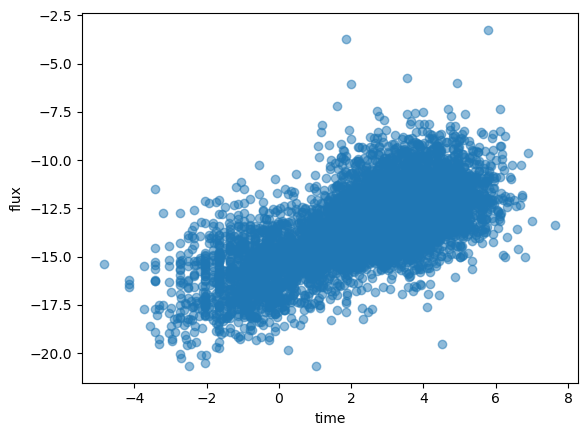

In [6]:
plt.plot(x,y, linewidth = 0, marker = 'o', alpha = 0.5)
plt.xlabel('time')
plt.ylabel('flux')

In [7]:
data = np.array([x,y]).T

## K-means clustering

In [8]:
clf = KMeans(n_clusters=2,n_init='auto')

In [9]:
clf.fit(data)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(data) #labels for each of the points

(array([5664.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2115.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

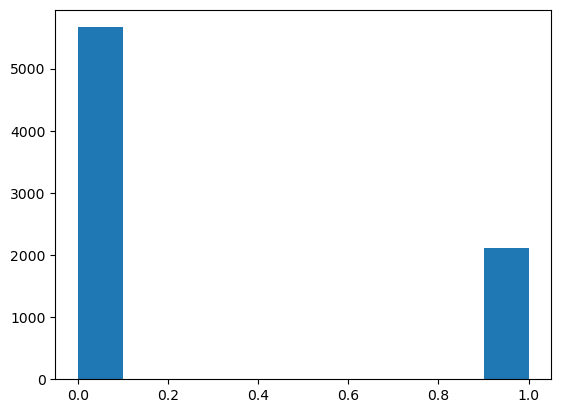

In [10]:
plt.hist(labels)

In [11]:
centers

array([[  3.50363553, -12.55414491],
       [  0.13940714, -15.4544649 ]])

Text(0, 0.5, 'log(f)')

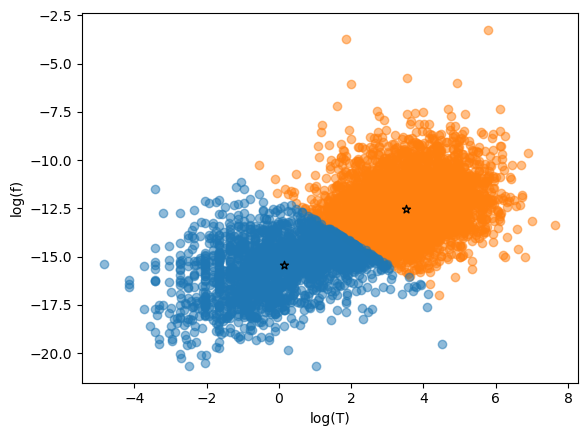

In [12]:
colors = ['C1', 'C0']
for ii in range(2):
    plt.scatter(data[labels==ii,0], data[labels==ii,1], 
                color=colors[ii],alpha=0.5)
    plt.scatter(centers[ii,0], centers[ii,1], color=colors[ii], marker = '*', edgecolors='black')

plt.xlabel('log(T)')
plt.ylabel('log(f)')

## Mean-shift clustering

In [33]:
scaler = preprocessing.StandardScaler()
bandwidth = .8
#bandwidth = estimate_bandwidth(X_reduced) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform(data))

,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",0.8
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",True
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary ` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300


[-1  0  1  2  3  4]
0.8
number of estimated clusters : 5


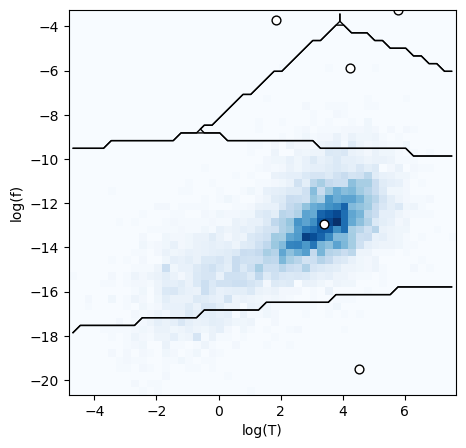

In [34]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(data[:,0], data[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('log(T)')
ax.set_ylabel('log(f)')

plt.show()